# **DATA 543 Spring 2026: CA Energy Prices**

In [ ]:
########################################################################
# Base Packages
########################################################################

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import datetime
from datetime import timedelta
import matplotlib.pyplot as plt
import scipy.stats
import warnings

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
###################################################################
# Import Data from the Github Repo and Clean + Format
###################################################################

base_path = 'Local Data/'
start_date = '2010-01-09'
end_date = '2025-12-31'

df_localtemps = pd.read_csv(base_path +'local_weather.csv') #daily temp observations, precipitation at Shasta Dam
df_localtemps = df_localtemps.drop(columns=['STATION', 'NAME', 'DAPR', 'MDPR', 'SNOW', 'SNWD'])
df_localtemps['DATE'] = pd.to_datetime(df_localtemps['DATE'], format='mixed')
df_localtemps.columns = ['Date', 'Precipitation', 'Max Temp (F)', 'Min Temp (F)', 'Observed Temp (F)']
df_localtemps = df_localtemps.set_index('Date').sort_index()

df_hdd_cdd = pd.read_csv(base_path + 'hdd_cdd.csv') #monthly hdd and cdd
df_hdd_cdd['Date'] = pd.to_datetime(df_hdd_cdd['Date'], format='%Y%m')
df_hdd_cdd = df_hdd_cdd.set_index('Date').sort_index()
df_hdd_cdd = df_hdd_cdd.resample('D').ffill() #fill out monthly data to days

df_ONI = pd.read_csv(base_path + 'Monthly Oceanic Nino Index (ONI) - Long.csv') #monthly
df_ONI['Date'] = pd.to_datetime(dict(year=df_ONI['Year'], month=df_ONI['MonthNum'], day=1)) #dataframe ends 12-01-2025 not 12-31 so need to manually add the extra days so that there are no NaN entries to the model
df_ONI = df_ONI.set_index('Date').sort_index()
df_ONI = df_ONI.drop(columns = ['Year', 'MonthTxt', 'MonthNum'])
last = df_ONI.index.max()
next_month = last + pd.offsets.MonthBegin(1)
df_ONI.loc[next_month] = df_ONI.loc[last]
df_ONI = df_ONI.resample('D').ffill()
df_ONI.columns = ['ONI']

df_pricedata = pd.read_csv(base_path + 'price_data.csv')
df_pricedata.columns = ['Date', 'PX_LAST', 'Lag [t-1]', 'Lag [t-7]', 'Rolling Average [7d]', 'Rolling Average [30d]', 'NatGas Lag [t-1]', 'NatGas Lag [t-7]', 'NatGas Rolling [7d]', 'NatGas Rolling [30d]', 'NatGas Rolling 2 [30d]'] #temporary we can name these whatever evenutally
df_pricedata['Date'] = pd.to_datetime(df_pricedata['Date'], format='%m/%d/%Y')
df_pricedata = df_pricedata.set_index('Date').sort_index()
df_pricedata = df_pricedata.drop(columns = ['NatGas Rolling 2 [30d]'])

dfs = [df_hdd_cdd, df_ONI, df_localtemps, df_pricedata] #add new dataframes here

####################################################################################
# double check no duplicates, aligned indexes, etc. to prepare for splice and join
####################################################################################

cleaned = []
for df in dfs:
    df = df.copy()
    df.index = pd.to_datetime(df.index, errors="coerce")
    df = df[~df.index.isna()]
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]
    cleaned.append(df)
dfs = cleaned
dfs = [df.loc[start_date:end_date] for df in dfs]
df_hdd_cdd, df_ONI, df_localtemps, df_pricedata = dfs

    
dfs = [df.loc[start_date:end_date] for df in dfs]
df_hdd_cdd, df_ONI, df_localtemps, df_pricedata = dfs #add back in any new dataframes

####################################################################################
# Final Concatenation, Formatting to feed into ML models
####################################################################################

monthly_df_list = [df_hdd_cdd, df_ONI]
daily_df_list = [df_pricedata, df_localtemps]

df_monthly = pd.concat(monthly_df_list, axis=1, join='outer') #join into seperate sets for later
df_daily = pd.concat(daily_df_list, axis=1, join='outer')

n_vars_monthly = df_monthly.shape[1] #variable so we don't have to mess with stuff in the model as we add stuff
n_vars_daily = df_daily.shape[1]

combined_df = pd.concat([df_monthly, df_daily], axis = 1, join = 'outer') #one total dataframe

In [29]:
df_daily

,PX_LAST,Lag [t-1],Lag [t-7],Rolling Average [7d],Rolling Average [30d],NatGas Lag [t-1],NatGas Lag [t-7],NatGas Rolling [7d],NatGas Rolling [30d],Precipitation,Max Temp (F),Min Temp (F),Observed Temp (F)
Date,,,,,,,,,,,,,
2010-01-09,48.46,55.16,45.14,51.217143,50.457500,5.92,5.92,6.248,6.248000,0.16,47.0,41.0,45.897837
2010-01-10,48.37,48.46,50.90,50.855714,50.225556,5.92,5.92,6.248,6.248000,0.05,54.0,45.0,46.086377
2010-01-11,53.43,48.37,50.21,51.315714,50.546000,5.85,5.95,6.182,6.193333,0.00,56.0,42.0,43.103282
2010-01-12,52.36,53.43,51.60,51.424286,50.710909,5.90,6.11,6.100,6.144286,0.95,50.0,43.0,45.168006
2010-01-13,49.04,52.36,49.69,51.331429,50.571667,6.07,6.03,6.042,6.113750,2.57,52.0,45.0,47.043405
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,17.35,30.33,0.00,21.834286,38.462000,3.00,2.24,2.410,3.486923,1.90,56.0,35.0,35.000000
2025-12-28,17.35,17.35,0.00,24.312857,37.372000,3.00,2.24,2.410,3.486923,0.00,50.0,35.0,44.909204
2025-12-29,33.23,17.35,0.00,29.060000,36.798000,3.00,2.24,2.300,3.486923,0.00,56.0,43.0,46.998529


In [30]:
df_monthly

,HDD (F),CDD (F),ONI
Date,,,
2010-01-09,492,0,1.3
2010-01-10,492,0,1.3
2010-01-11,492,0,1.3
2010-01-12,492,0,1.3
2010-01-13,492,0,1.3
...,...,...,...
2025-12-27,358,5,-0.5
2025-12-28,358,5,-0.5
2025-12-29,358,5,-0.5


X_daily any NaN: False
X_month any NaN: False
y any NaN: False
X_daily any Inf: False
X_month any Inf: False
y any Inf: False
X_daily: (5814, 13, 15)
X_month: (5814, 3)
y: (5814, 7)
Epoch 01 | Train Loss: 402.4667 | Val Loss: 1190.2053
Epoch 02 | Train Loss: 270.8022 | Val Loss: 1265.1885
Epoch 03 | Train Loss: 246.1968 | Val Loss: 1147.5746
Epoch 04 | Train Loss: 234.9069 | Val Loss: 1119.6481
Epoch 05 | Train Loss: 249.4450 | Val Loss: 1018.4141
Epoch 06 | Train Loss: 231.5126 | Val Loss: 976.5008
Epoch 07 | Train Loss: 226.1105 | Val Loss: 974.1256
Epoch 08 | Train Loss: 221.3090 | Val Loss: 907.1896
Epoch 09 | Train Loss: 218.5470 | Val Loss: 1307.3659
Epoch 10 | Train Loss: 215.7391 | Val Loss: 934.0378
Epoch 11 | Train Loss: 214.0521 | Val Loss: 1097.6267
Epoch 12 | Train Loss: 208.6157 | Val Loss: 929.3971
Epoch 13 | Train Loss: 207.8979 | Val Loss: 961.0615
Epoch 14 | Train Loss: 212.6755 | Val Loss: 964.0485
Epoch 15 | Train Loss: 205.0162 | Val Loss: 954.2797
Epoch 16 | Train

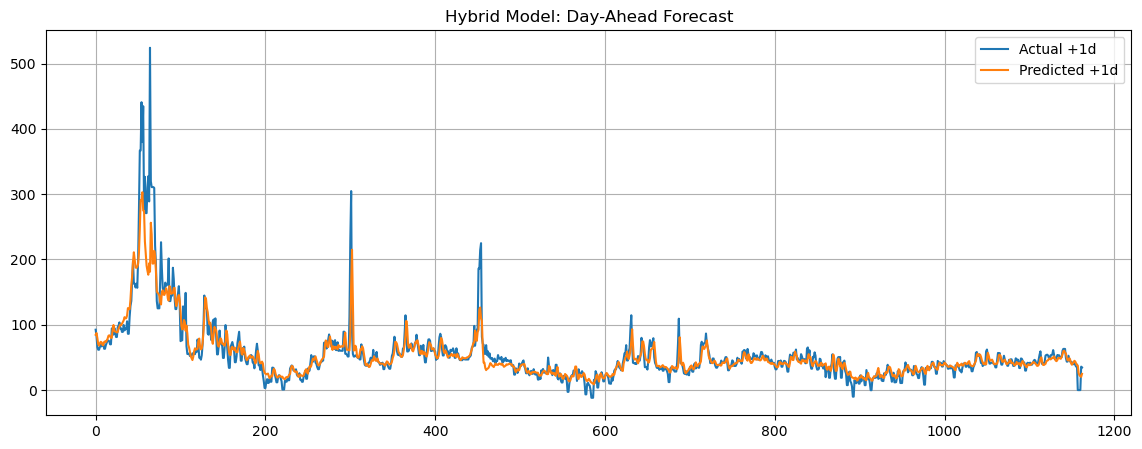

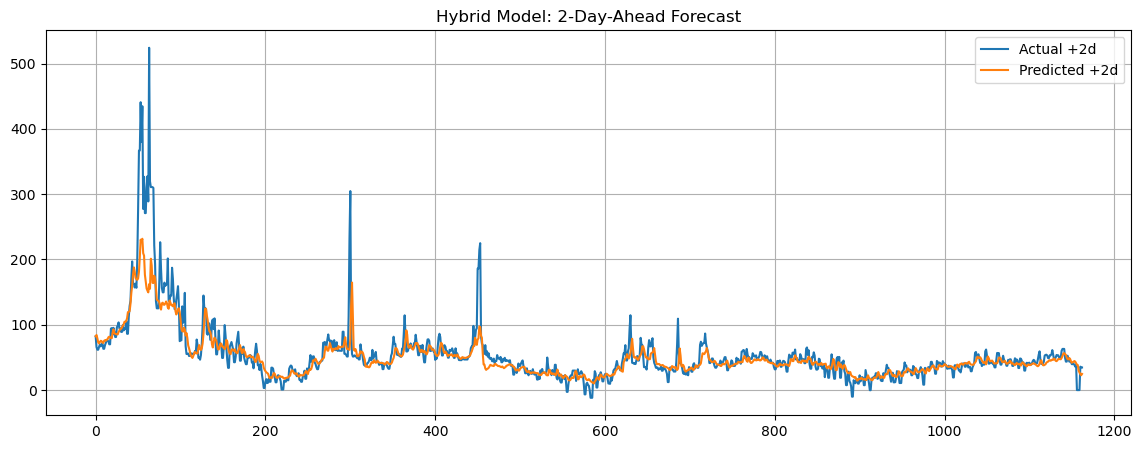

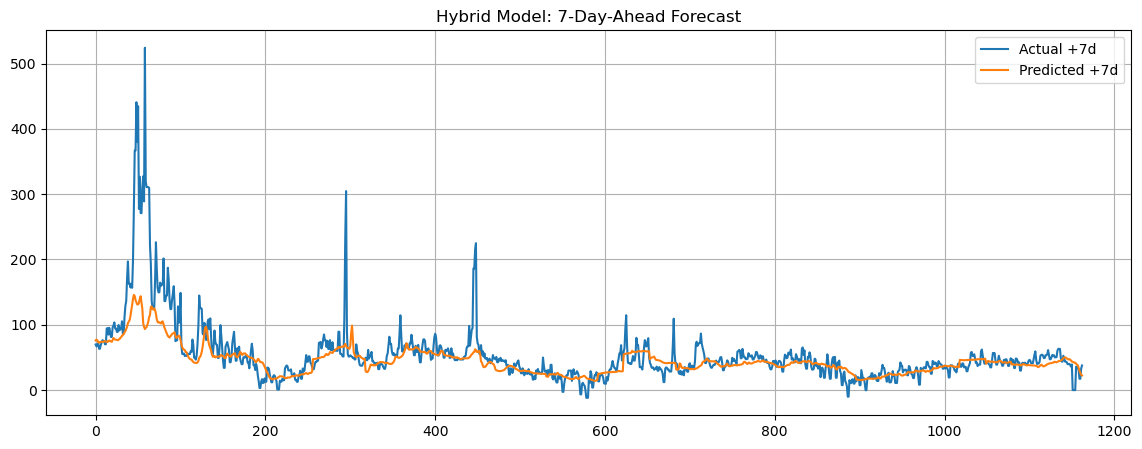

In [ ]:
############################################################################

#print("df_daily NaNs:\n", df_daily.isna().sum())  ####DATA CLEANING CHECKS
#print("df_monthly NaNs:\n", df_monthly.isna().sum())
#print("df_daily index freq:", df_daily.index.inferred_freq)
#print("df_monthly index freq:", df_monthly.index.inferred_freq)

############################################################################
#Create sliding windows with daily + monthly features
#  X_daily: (samples, n_vars_daily, window)
#  X_month: (samples, n_vars_monthly)
#  y:       (samples, horizon)
############################################################################

def create_hybrid_windows(daily_df, monthly_daily_df, window=15, horizon=7):
    X_daily, X_month, y = [], [], []
    daily_vals = daily_df.values
    monthly_vals = monthly_daily_df.values
    n = len(daily_df)

    for i in range(n - window - horizon):
        X_daily.append(daily_vals[i:i+window].T)  # (vars, window)
        X_month.append(monthly_vals[i+window-1])  # (3,) # Monthly features taken at the last day of the window
        y.append(daily_vals[i+window:i+window+horizon, 0]) # Target: next horizon days of first daily variable (PX_LAST!!!)
    
    print("X_daily any NaN:", np.isnan(X_daily).any())
    print("X_month any NaN:", np.isnan(X_month).any())
    print("y any NaN:", np.isnan(y).any())

    print("X_daily any Inf:", np.isinf(X_daily).any())
    print("X_month any Inf:", np.isinf(X_month).any())
    print("y any Inf:", np.isinf(y).any())

    return np.array(X_daily), np.array(X_month), np.array(y)

window = 15
horizon = 7

X_daily, X_month, y = create_hybrid_windows(
    df_daily,
    df_monthly,
    window=window,
    horizon=horizon
)

print("X_daily:", X_daily.shape)
print("X_month:", X_month.shape)  
print("y:", y.shape)               

######################################################################
# Dataset + DataLoader
######################################################################

class HybridClimateDataset(Dataset):
    def __init__(self, X_daily, X_month, y):
        self.X_daily = torch.tensor(X_daily, dtype=torch.float32)
        self.X_month = torch.tensor(X_month, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X_daily)

    def __getitem__(self, idx):
        return self.X_daily[idx], self.X_month[idx], self.y[idx]

split = int(0.8 * len(X_daily))
train_ds = HybridClimateDataset(X_daily[:split], X_month[:split], y[:split])
val_ds   = HybridClimateDataset(X_daily[split:], X_month[split:], y[split:])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)

##########################################################################
# Month/Day Hybid model
##########################################################################

class HybridCNN(nn.Module):
    def __init__(self, in_channels_daily, monthly_features, horizon):
        super().__init__()

        # Daily CNN branch
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels_daily, 32, kernel_size=5, padding=2), #padding prevents data loss on the edges of the set
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        # Monthly MLP branch
        self.mlp = nn.Sequential(
            nn.Linear(monthly_features, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        # Fusion + output
        self.fc = nn.Sequential(
            nn.Linear(64 + 32, 64),
            nn.ReLU(),
            nn.Linear(64, horizon)
        )

    def forward(self, x_daily, x_month):
        daily_latent = self.cnn(x_daily).squeeze(-1)  # (batch, 64)
        month_latent = self.mlp(x_month)              # (batch, 32)
        fused = torch.cat([daily_latent, month_latent], dim=1)
        return self.fc(fused)

model = HybridCNN(
    in_channels_daily=n_vars_daily,
    monthly_features=n_vars_monthly,
    horizon=horizon
)

################################################################
# Training Loop
################################################################

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for xb_daily, xb_month, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb_daily, xb_month)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb_daily, xb_month, yb in val_loader:
            pred = model(xb_daily, xb_month)
            val_loss += criterion(pred, yb).item()

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f}")

###############################################################
# Prediction Set
###############################################################

model.eval()
preds, actuals = [], []
with torch.no_grad():
    for xb_daily, xb_month, yb in val_loader:
        preds.append(model(xb_daily, xb_month).numpy())
        actuals.append(yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

###############################################################
# Results/Plotting
###############################################################

# Day-ahead (horizon 1)
plt.figure(figsize=(14,5))
plt.plot(actuals[:,0], label="Actual +1d")
plt.plot(preds[:,0], label="Predicted +1d")
plt.title("Hybrid Model: Day-Ahead Forecast",fontweight = 'semibold')
plt.legend()
plt.grid(True)
plt.show()

# 2-day-ahead (horizon 2)
plt.figure(figsize=(14,5))
plt.plot(actuals[:,1], label="Actual +2d")
plt.plot(preds[:,1], label="Predicted +2d")
plt.title("Hybrid Model: 2-Day-Ahead Forecast",fontweight = 'semibold')
plt.legend()
plt.grid(True)
plt.show()

# 7-day-ahead (horizon 7)
plt.figure(figsize=(14,5))
plt.plot(actuals[:,6], label="Actual +7d")
plt.plot(preds[:,6], label="Predicted +7d")
plt.title("Hybrid Model: 7-Day-Ahead Forecast",fontweight = 'semibold')
plt.legend()
plt.grid(True)
plt.show()

X_daily: (5819, 13, 10)
X_month: (5819, 3)
y: (5819, 7)
Epoch 01 | Train Loss: 5.6317 | Val Loss: 6.2223
Epoch 02 | Train Loss: 2.8200 | Val Loss: 5.8060
Epoch 03 | Train Loss: 2.7861 | Val Loss: 5.7323
Epoch 04 | Train Loss: 2.6941 | Val Loss: 5.3198
Epoch 05 | Train Loss: 2.6753 | Val Loss: 6.4880
Epoch 06 | Train Loss: 2.6340 | Val Loss: 6.0494
Epoch 07 | Train Loss: 2.6104 | Val Loss: 5.2441
Epoch 08 | Train Loss: 2.5929 | Val Loss: 6.0965
Epoch 09 | Train Loss: 2.5621 | Val Loss: 5.6984
Epoch 10 | Train Loss: 2.5343 | Val Loss: 4.6042
Epoch 11 | Train Loss: 2.5314 | Val Loss: 5.5563
Epoch 12 | Train Loss: 2.5185 | Val Loss: 5.6964
Epoch 13 | Train Loss: 2.4790 | Val Loss: 4.9231
Epoch 14 | Train Loss: 2.4481 | Val Loss: 4.6056
Epoch 15 | Train Loss: 2.4306 | Val Loss: 5.3822
Epoch 16 | Train Loss: 2.4286 | Val Loss: 4.9274
Epoch 17 | Train Loss: 2.4222 | Val Loss: 4.5063
Epoch 18 | Train Loss: 2.4054 | Val Loss: 5.3126
Epoch 19 | Train Loss: 2.3836 | Val Loss: 4.7350
Epoch 20 | Tr

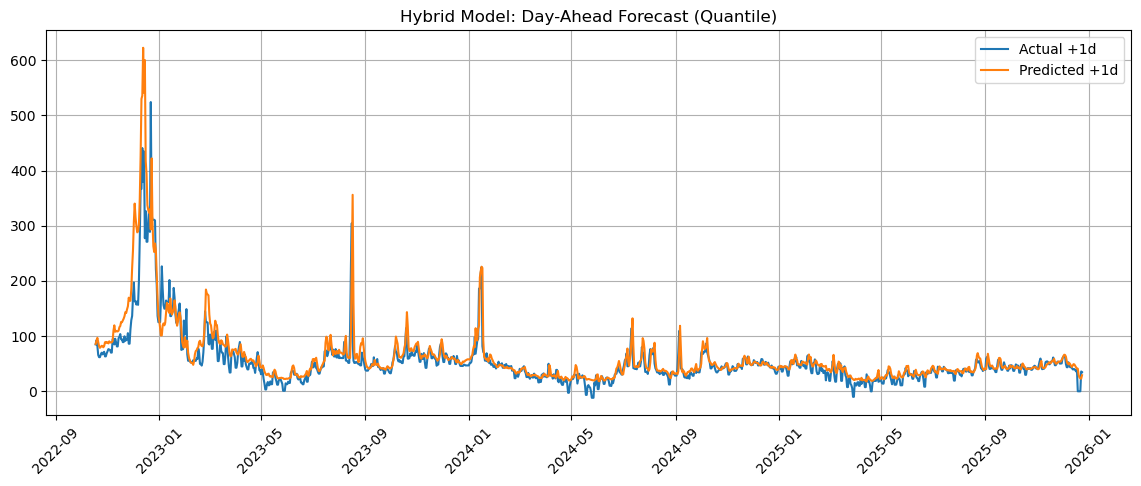

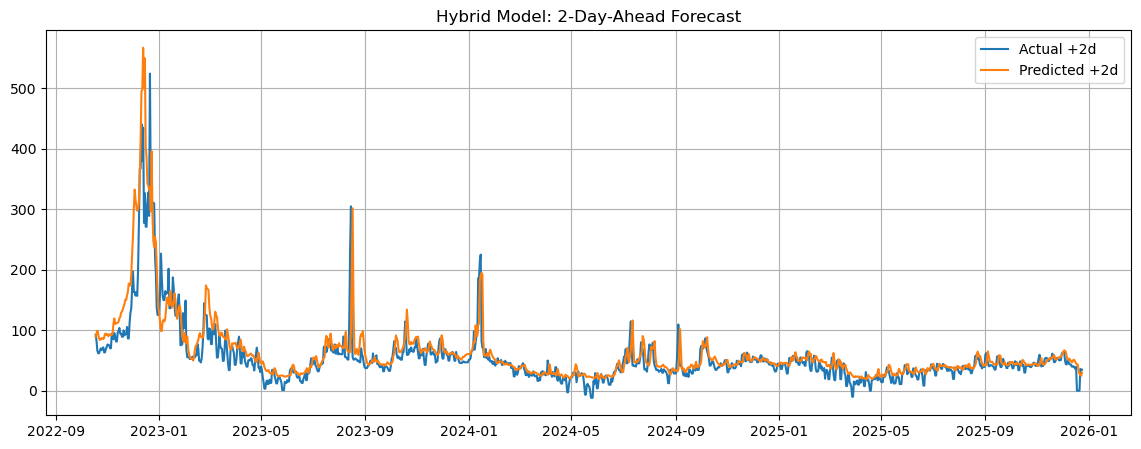

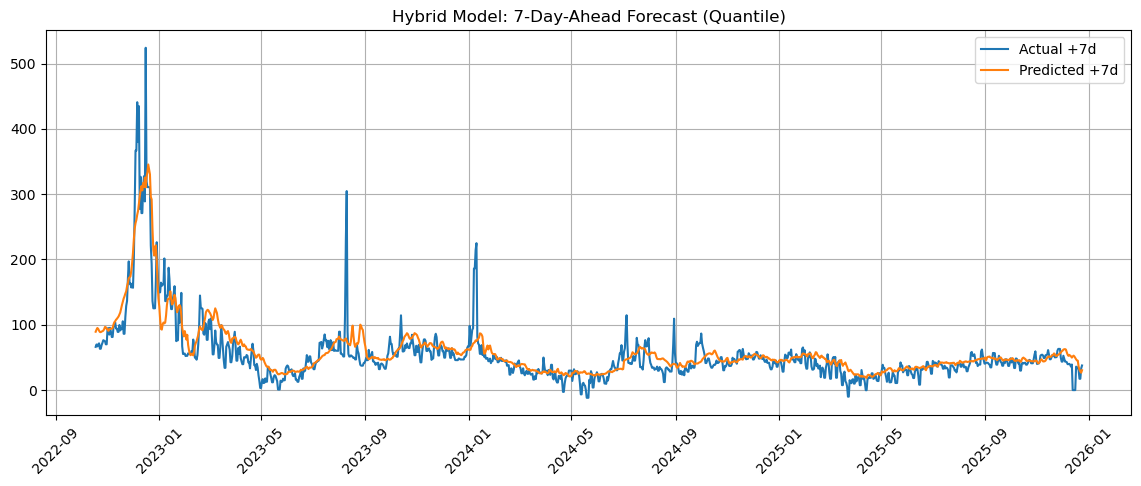

In [ ]:
############################################################################
# Try Same Process with Quantiles instead of RMSE
############################################################################

def create_hybrid_windows(daily_df, monthly_daily_df, window=10, horizon=7):
    X_daily, X_month, y = [], [], []
    daily_vals = daily_df.values
    monthly_vals = monthly_daily_df.values
    n = len(daily_df)

    for i in range(n - window - horizon):
        X_daily.append(daily_vals[i:i+window].T)  # (vars, window)
        X_month.append(monthly_vals[i+window-1])  # Monthly features taken at the last day of the window
        y.append(daily_vals[i+window:i+window+horizon, 0]) # Target: next horizon days of first daily variable

    # NaN checking
    X_daily_arr = np.array(X_daily)
    X_month_arr = np.array(X_month)
    y_arr       = np.array(y)

    #print("X_daily any NaN:", np.isnan(X_daily_arr).any())
    #print("X_month any NaN:", np.isnan(X_month_arr).any())
    #print("y any NaN:", np.isnan(y_arr).any())

    #print("X_daily any Inf:", np.isinf(X_daily_arr).any())
    #print("X_month any Inf:", np.isinf(X_month_arr).any())
    #print("y any Inf:", np.isinf(y_arr).any())

    return X_daily_arr, X_month_arr, y_arr

window = 10
horizon = 7

X_daily, X_month, y = create_hybrid_windows(
    df_daily,
    df_monthly,
    window=window,
    horizon=horizon
)

print("X_daily:", X_daily.shape)   
print("X_month:", X_month.shape)   
print("y:", y.shape)               

n_vars_daily   = X_daily.shape[1]
n_vars_monthly = X_month.shape[1]

######################################################################
# DataSet Class
######################################################################

class HybridClimateDataset(Dataset):
    def __init__(self, X_daily, X_month, y):
        self.X_daily = torch.tensor(X_daily, dtype=torch.float32)
        self.X_month = torch.tensor(X_month, dtype=torch.float32)
        self.y       = torch.tensor(y,       dtype=torch.float32)

    def __len__(self):
        return len(self.X_daily)

    def __getitem__(self, idx):
        return self.X_daily[idx], self.X_month[idx], self.y[idx]

split = int(0.8 * len(X_daily))
train_ds = HybridClimateDataset(X_daily[:split], X_month[:split], y[:split])
val_ds   = HybridClimateDataset(X_daily[split:], X_month[split:], y[split:])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

#######################################################################
# Hybrid model
#######################################################################

class HybridCNN(nn.Module):
    def __init__(self, in_channels_daily, monthly_features, horizon):
        super().__init__()

        # Daily CNN branch
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels_daily, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        # Monthly MLP branch
        self.mlp = nn.Sequential(
            nn.Linear(monthly_features, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        # Fusion + output
        self.fc = nn.Sequential(
            nn.Linear(64 + 32, 64),
            nn.ReLU(),
            nn.Linear(64, horizon)
        )

    def forward(self, x_daily, x_month):
        # x_daily: (batch, vars, window)
        daily_latent = self.cnn(x_daily).squeeze(-1)  # (batch, 64)
        month_latent = self.mlp(x_month)              # (batch, 32)
        fused = torch.cat([daily_latent, month_latent], dim=1)
        return self.fc(fused)

model = HybridCNN(
    in_channels_daily=n_vars_daily,
    monthly_features=n_vars_monthly,
    horizon=horizon
)

###################################################################
# Quantiles
###################################################################
def quantile_loss(q, y, f):
    e = y - f
    return torch.max(q * e, (q - 1) * e).mean()

q = 0.87  # Goal is to improve matching with peaks, volatility
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 25
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for xb_daily, xb_month, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb_daily, xb_month)
        loss = quantile_loss(q, yb, pred)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb_daily, xb_month, yb in val_loader:
            pred = model(xb_daily, xb_month)
            val_loss += quantile_loss(q, yb, pred).item()

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f}")

###################################################################
# Predictions on Validation Set
###################################################################

model.eval()
preds, actuals = [], []
with torch.no_grad():
    for xb_daily, xb_month, yb in val_loader:
        out = model(xb_daily, xb_month)
        preds.append(out.detach().numpy())
        actuals.append(yb.detach().numpy())

preds   = np.vstack(preds)
actuals = np.vstack(actuals)

#####################################################################
# Results/Plotting
#####################################################################

val_dates = df_daily.index[window + split : window + split + len(actuals)] #fix x-axis dates

# 1-day ahead
plt.figure(figsize=(14,5))
plt.plot(val_dates, actuals[:,0], label="Actual +1d")
plt.plot(val_dates, preds[:,0],   label=f"Predicted +1d")
plt.title("Hybrid Model: Day-Ahead Forecast (Quantile)",fontweight = 'semibold')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# 2-day ahead
plt.figure(figsize=(14,5))
plt.plot(val_dates, actuals[:,1], label="Actual +2d")
plt.plot(val_dates, preds[:,1], label="Predicted +2d")
plt.title("Hybrid Model: 2-Day-Ahead Forecast", fontweight = 'semibold')
plt.legend()
plt.grid(True)
plt.show()

#7-day ahead
plt.figure(figsize=(14,5))
plt.plot(val_dates, actuals[:,6], label="Actual +7d")
plt.plot(val_dates, preds[:,6],   label=f"Predicted +7d")
plt.title("Hybrid Model: 7-Day-Ahead Forecast (Quantile)", fontweight = 'semibold')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


=== Horizon: 1-day ahead ===
OOB Score: 0.6415132854779779
MSE: 695.3364844882424
R-squared: 0.7195003569385425


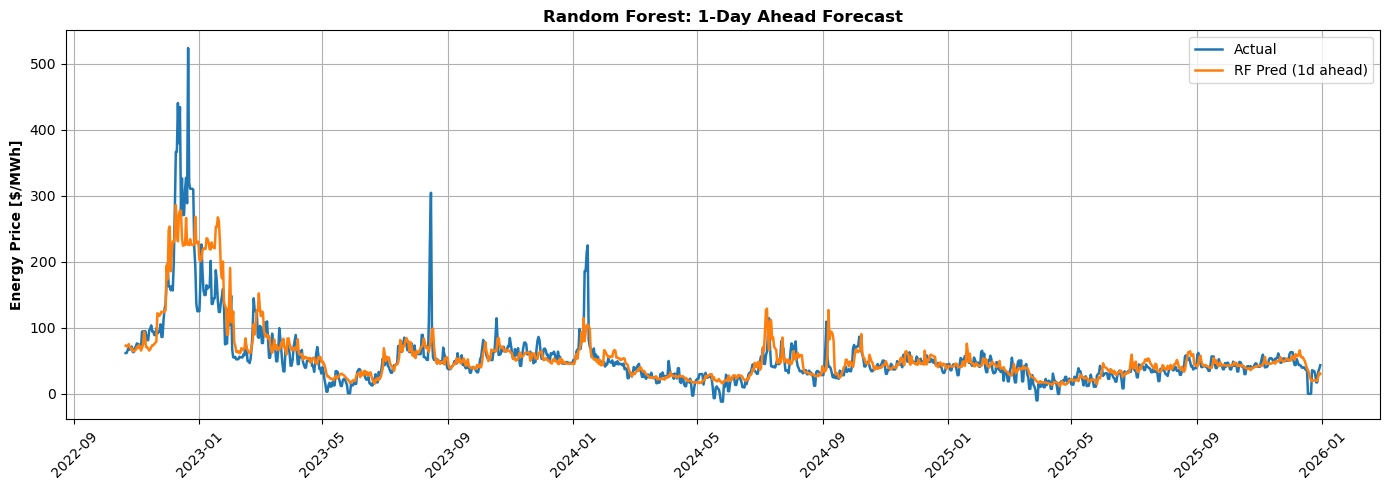


=== Horizon: 2-day ahead ===
OOB Score: 0.6750621280030733
MSE: 870.1778590783308
R-squared: 0.64896911881289


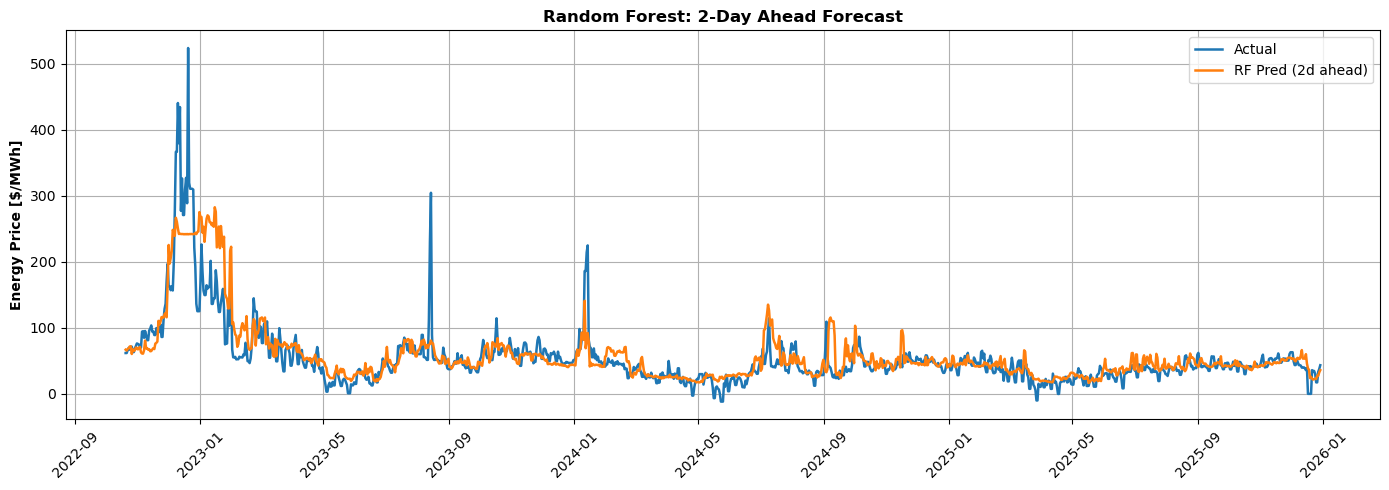


=== Horizon: 7-day ahead ===
OOB Score: 0.7049933964528017
MSE: 1219.7472458965613
R-squared: 0.5083625655592893


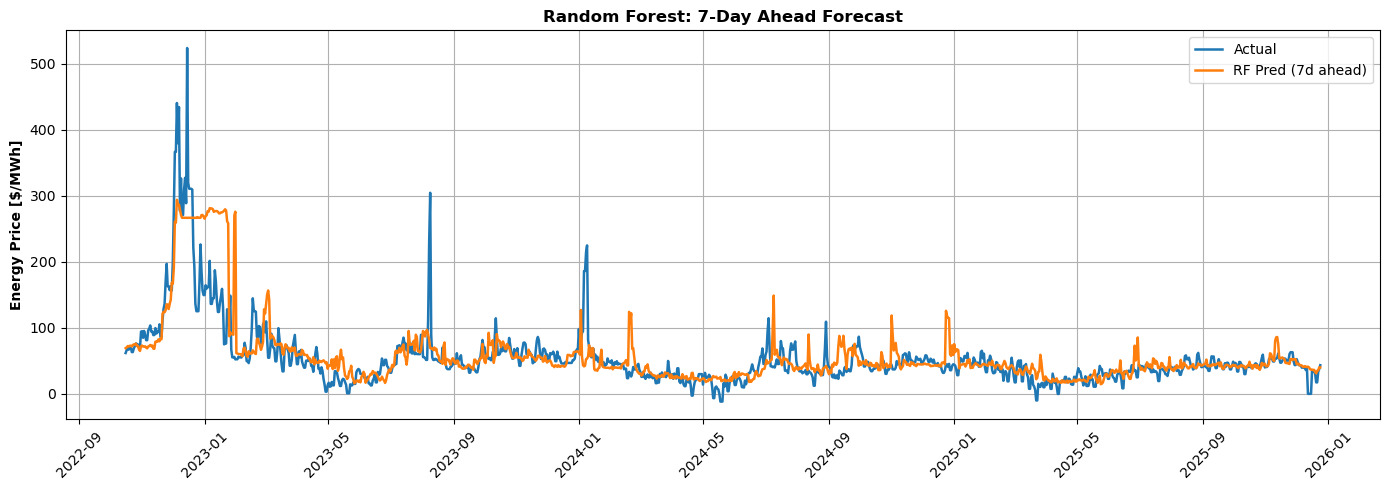


=== Forecast Metrics by Horizon ===


,Horizon (days),OOB Score,MAE,MSE,RMSE,R-squared
0,1,0.6415,13.956,695.336,26.369,0.7195
1,2,0.6751,16.313,870.178,29.499,0.6490
2,7,0.7050,18.303,1219.747,34.925,0.5084


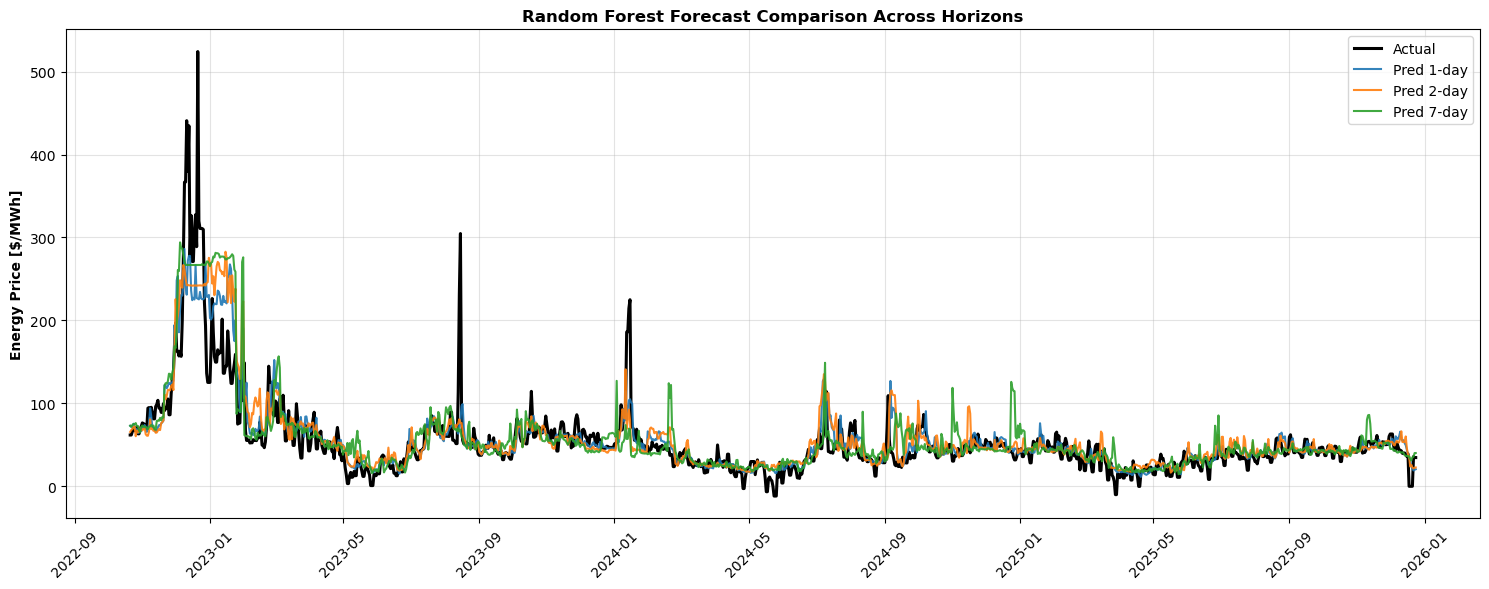

In [ ]:
##########################################################################
# Random Forest Model for Comparison to CNN
##########################################################################

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#########################################################################
# Assign Features and Target
#########################################################################
df_rf = df_daily.copy()
df_rf.info()

feature_cols = df_rf.columns[1:n_vars_daily]  # lag/rolling/weather features
target_col = "PX_LAST"

#########################################################################
# Main Model Function
#########################################################################

def rf_horizon(df, feature_cols, target_col, horizon_days, test_size=0.2):
    """
    Direct forecast for a fixed horizon:
    y_t = target at t + horizon_days
    """
    data = df.copy()
    data[f"target_t_plus_{horizon_days}"] = data[target_col].shift(-horizon_days)

    # drop rows with NaN target created by shifting
    data = data.dropna(subset=[f"target_t_plus_{horizon_days}"])

    X = data[feature_cols]
    y = data[f"target_t_plus_{horizon_days}"]
    split_idx = int((1 - test_size) * len(data))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:] #chronological split
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    model = RandomForestRegressor(n_estimators=300,random_state=42,oob_score=True,n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n=== Horizon: {horizon_days}-day ahead ===")
    print("OOB Score:", model.oob_score_)
    print("MSE:", mse)
    print("R-squared:", r2)

    # Plot only test window (cleaner than plotting full-sample predictions)
    plt.figure(figsize=(14, 5))
    plt.plot(y_test.index, y_test.values, label="Actual", linewidth=1.8)
    plt.plot(y_test.index, y_pred, label=f"RF Pred ({horizon_days}d ahead)", linewidth=1.8)
    plt.title(f"Random Forest: {horizon_days}-Day Ahead Forecast", fontweight="semibold")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.ylabel("Energy Price [$/MWh]", fontweight="semibold")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return model, pd.Series(y_pred, index=y_test.index, name=f"pred_t_plus_{horizon_days}")

###############################################################################################
#Set up Prediction Intervals and Run Model
###############################################################################################

models = {}
preds = {}

for h in [1, 2, 7]:
    models[h], preds[h] = rf_horizon(
        df=df_rf,
        feature_cols=feature_cols,
        target_col=target_col,
        horizon_days=h,
        test_size=0.2
    )

################################################################################################
# Metrics/Summary Statistics
################################################################################################

horizons = [1, 2, 7]
metrics_rows = []
actual_by_h = {}
pred_by_h = {}

for h in horizons:
    data_h = df_rf.copy() # rebuild for this prediction interval
    data_h[f"target_t_plus_{h}"] = data_h[target_col].shift(-h)
    data_h = data_h.dropna(subset=[f"target_t_plus_{h}"])

    X_h = data_h[feature_cols]
    y_h = data_h[f"target_t_plus_{h}"]

    split_idx = int(0.8 * len(data_h))
    X_test_h = X_h.iloc[split_idx:]
    y_test_h = y_h.iloc[split_idx:]

    y_pred_h = models[h].predict(X_test_h)

    # store for table
    mse_h = mean_squared_error(y_test_h, y_pred_h)
    rmse_h = mse_h ** 0.5
    mae_h = mean_absolute_error(y_test_h, y_pred_h)
    r2_h = r2_score(y_test_h, y_pred_h)

    metrics_rows.append({
        "Horizon (days)": h,
        "OOB Score": models[h].oob_score_,
        "MAE": mae_h,
        "MSE": mse_h,
        "RMSE": rmse_h,
        "R-squared": r2_h
    })

    actual_by_h[h] = y_test_h
    pred_by_h[h] = pd.Series(y_pred_h, index=y_test_h.index, name=f"pred_t_plus_{h}")

metrics_df = pd.DataFrame(metrics_rows).sort_values("Horizon (days)").reset_index(drop=True)
print("\n=== Forecast Metrics by Horizon ===")
display(metrics_df.style.format({
    "OOB Score": "{:.4f}",
    "MAE": "{:.3f}",
    "MSE": "{:.3f}",
    "RMSE": "{:.3f}",
    "R-squared": "{:.4f}"
}))

###############################################################################################
# Results/Plotting
###############################################################################################

common_idx = actual_by_h[1].index
for h in horizons[1:]:
    common_idx = common_idx.intersection(actual_by_h[h].index)

plot_df = pd.DataFrame(index=common_idx)
plot_df["Actual (t+h)"] = actual_by_h[1].loc[common_idx]  # same underlying series on common_idx
for h in horizons:
    plot_df[f"Pred {h}d"] = pred_by_h[h].loc[common_idx]

plt.figure(figsize=(15, 6))
plt.plot(plot_df.index, plot_df["Actual (t+h)"], label="Actual", linewidth=2.2, color="black")
plt.plot(plot_df.index, plot_df["Pred 1d"], label="Pred 1-day")
plt.plot(plot_df.index, plot_df["Pred 2d"], label="Pred 2-day")
plt.plot(plot_df.index, plot_df["Pred 7d"], label="Pred 7-day")

plt.title("Random Forest Forecast Comparison Across Horizons", fontweight="semibold")
plt.grid(True) #alpha=0.5
plt.xticks(rotation=45)
plt.ylabel("Energy Price [$/MWh]", fontweight="semibold")
plt.legend()
plt.tight_layout()
plt.show()